In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import seaborn as sns
import openpyxl

In [3]:
def clean_date(data, name_column):
    data[name_column] = data[name_column].astype(str)
    data[name_column] = data[name_column].apply(lambda x: x[0:10])

    return data

In [4]:
prices = pd.read_excel("C:\\Users\\miche\\OneDrive\\Documenti\\PROJECTS\\crude oil forecasting\\prices\\prices_WTI_brent_spot.xls", sheet_name = "Data 1")


In [5]:
prices = clean_date(prices, "Back to Contents")
prices.columns = ["Date", "WTI_Spot_Price", "Brent_Spot_Price"]
prices.set_index("Date", inplace=True)

In [6]:
prices.dropna(subset=["Brent_Spot_Price"], inplace=True)
prices = prices.iloc[2:,:]

In [7]:
prices.fillna(0, inplace = True)

C:\Users\miche\AppData\Local\Temp\ipykernel_65848\3653037392.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  prices.fillna(0, inplace = True)


In [8]:
prices.index = pd.to_datetime(prices.index)

In [9]:
log_WTI = 100 * np.log(prices["WTI_Spot_Price"]/prices["WTI_Spot_Price"].shift(1))
log_WTI.dropna(inplace=True)
log_WTI = pd.DataFrame(log_WTI)
log_WTI.columns = ["Log_Returns_WTI"]
log_Brent = 100 * np.log(prices["Brent_Spot_Price"]/prices["Brent_Spot_Price"].shift(1))
log_Brent.dropna(inplace=True)
log_Brent = pd.DataFrame(log_Brent)
log_Brent.columns = ["Log_Returns_Brent"]

c:\Users\miche\OneDrive\Documenti\PROJECTS\crude oil forecasting\crude_oil_ml\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\miche\OneDrive\Documenti\PROJECTS\crude oil forecasting\crude_oil_ml\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [10]:
log_WTI = log_WTI.applymap(lambda x: x if np.isfinite(x) else 0)
log_Brent = log_Brent.applymap(lambda x: x if np.isfinite(x) else 0)

C:\Users\miche\AppData\Local\Temp\ipykernel_65848\3605550843.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_WTI = log_WTI.applymap(lambda x: x if np.isfinite(x) else 0)
C:\Users\miche\AppData\Local\Temp\ipykernel_65848\3605550843.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  log_Brent = log_Brent.applymap(lambda x: x if np.isfinite(x) else 0)


In [11]:
RV_WTI_day = log_WTI.pow(2).resample("D").sum().pow(0.5).rename(columns = {"Log_Returns_WTI":"RV_WTI_day"})
RV_Brent_day = log_Brent.pow(2).resample("D").sum().pow(0.5).rename(columns = {"Log_Returns_Brent":"RV_Brent_day"})

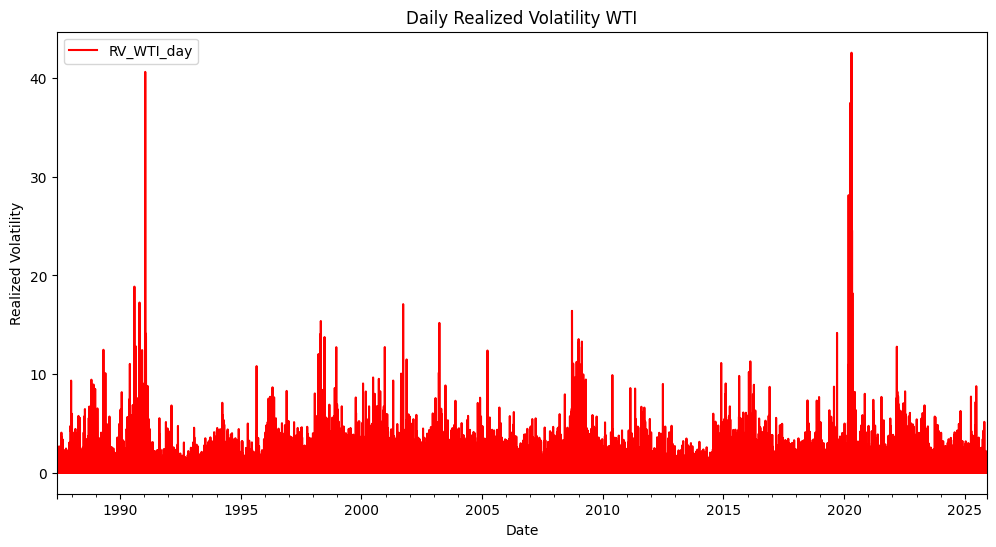

In [12]:
RV_WTI_day.plot(figsize=(12,6), title="Daily Realized Volatility WTI", color="red")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()


In [13]:
RV_WTI_day.to_csv('daily_realized_volatility_WTI.csv')
RV_Brent_day.to_csv('daily_realized_volatility_Brent.csv')

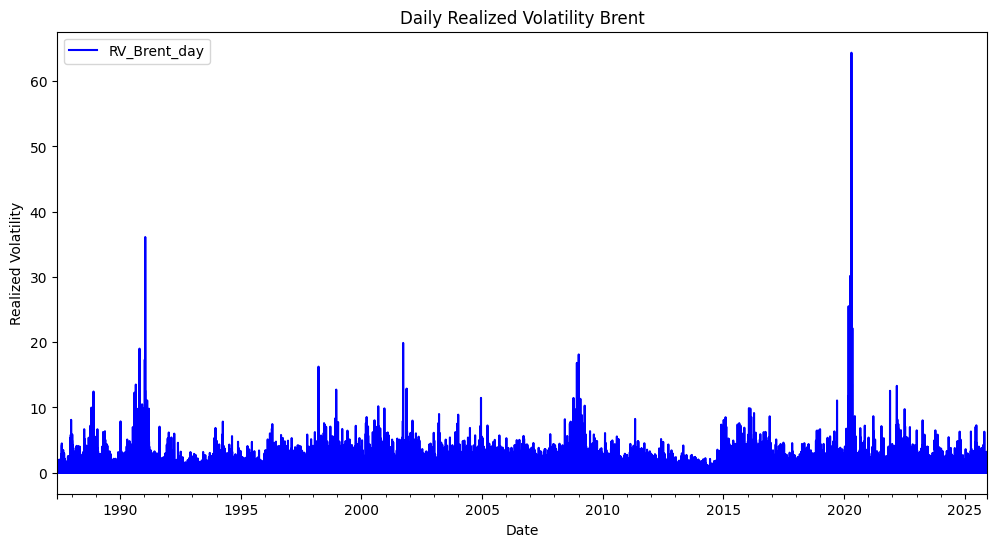

In [14]:
RV_Brent_day.plot(figsize=(12,6), title="Daily Realized Volatility Brent", color="blue")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()

In [15]:
RV_Brent_week = log_Brent.pow(2).resample("W").sum().pow(0.5).rename(columns = {"Log_Returns_Brent":"RV_Brent_week"})
RV_WTI_week = log_WTI.pow(2).resample("W").sum().pow(0.5).rename(columns = {"Log_Returns_WTI":"RV_WTI_week"})

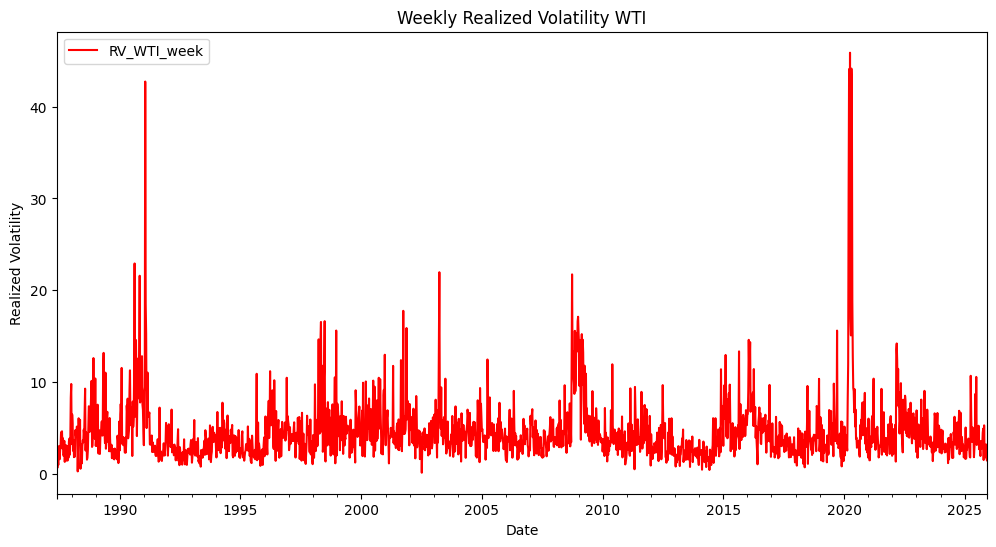

In [16]:
RV_WTI_week.plot(figsize=(12,6), title="Weekly Realized Volatility WTI", color="red")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()

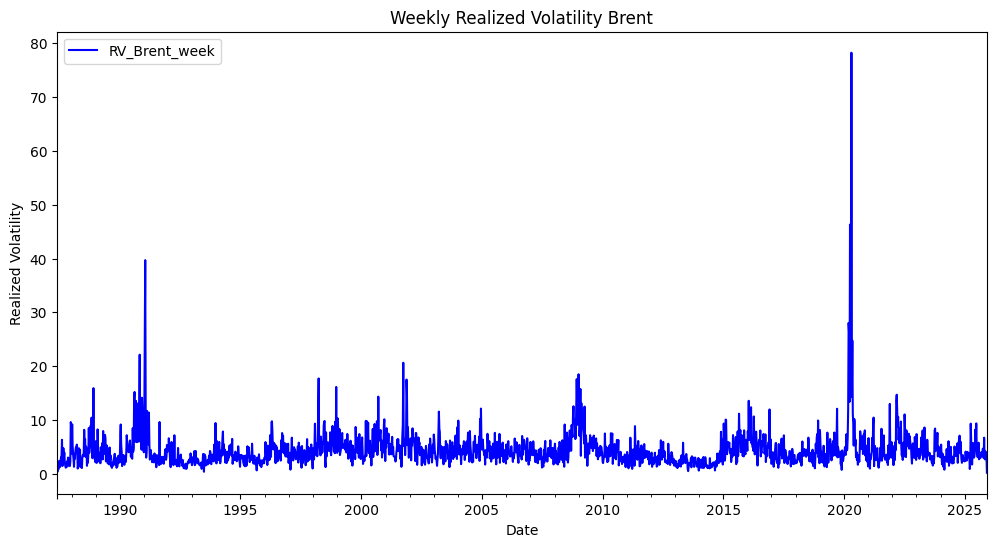

In [17]:
RV_Brent_week.plot(figsize=(12,6), title="Weekly Realized Volatility Brent", color="blue")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()


In [18]:
RV_Brent_week.to_csv('weekly_realized_volatility_Brent.csv')
RV_WTI_week.to_csv('weekly_realized_volatility_WTI.csv')

In [19]:
RV_WTI_month = log_WTI.pow(2).resample("M").sum().pow(0.5).rename(columns = {"Log_Returns_WTI":"RV_WTI_month"})
RV_Brent_month = log_Brent.pow(2).resample("M").sum().pow(0.5).rename(columns = {"Log_Returns_Brent":"RV_Brent_month"})

C:\Users\miche\AppData\Local\Temp\ipykernel_65848\595791959.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  RV_WTI_month = log_WTI.pow(2).resample("M").sum().pow(0.5).rename(columns = {"Log_Returns_WTI":"RV_WTI_month"})
C:\Users\miche\AppData\Local\Temp\ipykernel_65848\595791959.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  RV_Brent_month = log_Brent.pow(2).resample("M").sum().pow(0.5).rename(columns = {"Log_Returns_Brent":"RV_Brent_month"})


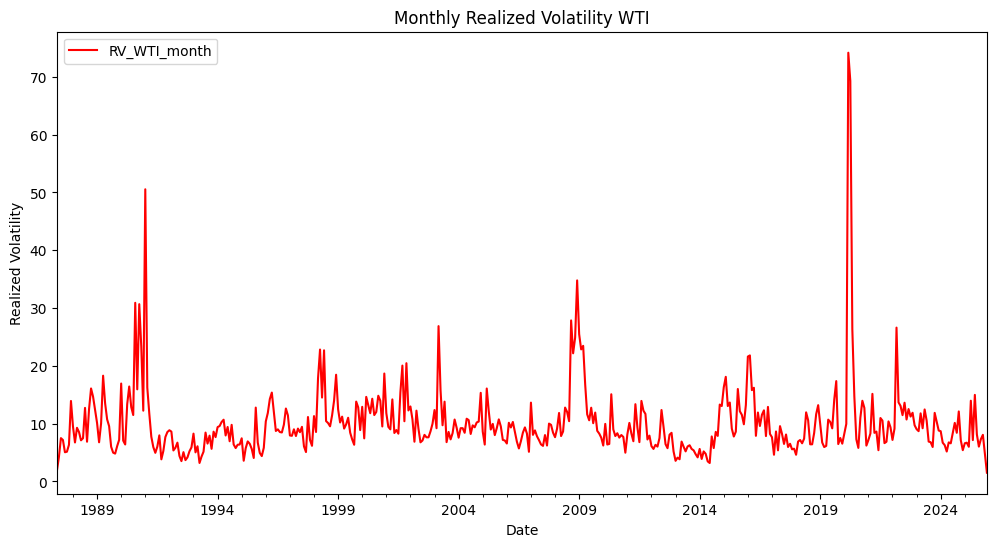

In [20]:
RV_WTI_month.plot(figsize=(12,6), title="Monthly Realized Volatility WTI", color="red")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()


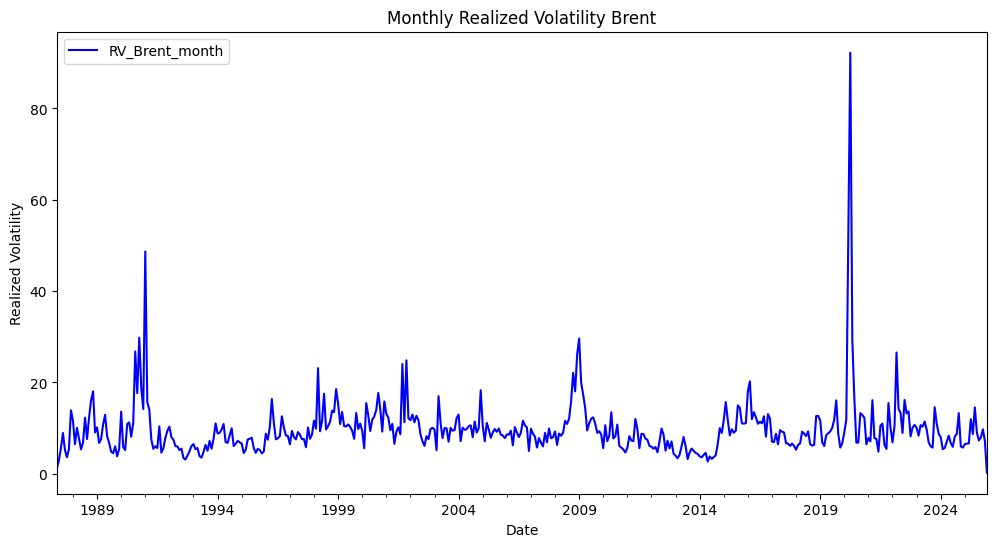

In [21]:
RV_Brent_month.plot(figsize=(12,6), title="Monthly Realized Volatility Brent", color="blue")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.show()

In [22]:
RV_WTI_month.to_csv('monthly_realized_volatility_WTI.csv')
RV_Brent_month.to_csv('monthly_realized_volatility_Brent.csv')